# OCR Model Testing Notebook
This notebook evaluates a trained OCR + text classifier model.

### Imports

In [26]:
# Imports
import sys
sys.path.append(r"C:\Users\ibf\Desktop\TFM\Nou_projecte")
from TFM.Utils.ocr_utils import *
import matplotlib.pyplot as plt
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\ibf\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
print(pytesseract.get_tesseract_version())


5.5.0.20241111


## Image Path

In [ ]:
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error funcional\Cartera\20260512020139_100139.png")
# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Error aplicativo\20260510012034_100036.png")

# IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Revisión circuito\20260519021151_100133.png")

## Paths

In [45]:

# Paths

ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
MODELS_DIR = ROOT / 'TFM' / 'Models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.90



## Load Model

In [ ]:

import joblib
import json
from sentence_transformers import SentenceTransformer
# Load embedding model
from pathlib import Path

# Base model folder
MODEL_PATH = ROOT / "TFM" / "Model_Notebooks" / "models" / "ocr_text_classifier_v3"

# Embedding model
embedding_model = SentenceTransformer(str(MODEL_PATH / "embedding_model"))

# Classifier
text_clf = joblib.load(str(MODEL_PATH / "orc_clf.joblib"))

# Class names
class_names = joblib.load(str(MODEL_PATH / "classes.joblib"))

# Config
with open(str(MODEL_PATH / "config.json"), "r", encoding="utf-8") as f:
    config = json.load(f)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4559.62it/s]


## Show results

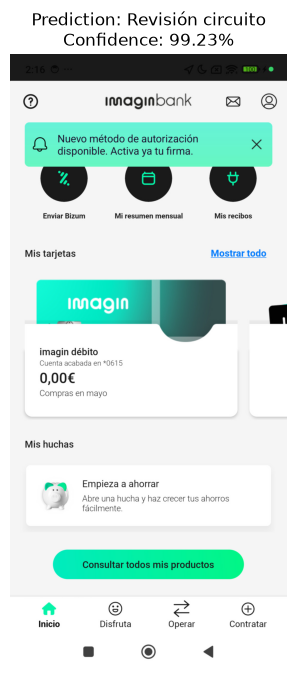

In [ ]:
IMAGE_PATH = Path(r"C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Revisión circuito\20260519021151_100133.png")

result = predict_text(
    image_path=IMAGE_PATH,
    model=embedding_model,
    clf=text_clf,
    threshold=CONFIDENCE_THRESHOLD
)

image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(5, 8))
plt.imshow(image)
plt.title(
    f"Prediction: {result['prediction']}\n"
    f"Confidence: {result['confidence']:.2%}"
)
plt.axis("off")
plt.show()